In [ ]:
import os
import shutil
import random
from pathlib import Path
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

In [ ]:
CLASS_DIRS = {
    "pho": "/content/drive/MyDrive/MonAnVietNam/phở",
    "banh_mi": "/content/drive/MyDrive/MonAnVietNam/bánh mì",
    "bun": "/content/drive/MyDrive/MonAnVietNam/bún",
    "bot_chien": "/content/drive/MyDrive/MonAnVietNam/bột chiên",
    "goi_cuon": "/content/drive/MyDrive/MonAnVietNam/gỏi cuốn",
}

IMG_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 30

for name, path in CLASS_DIRS.items():
    print(name, "=>", path, "|", "OK" if os.path.exists(path) else "SAI PATH")

pho => /content/drive/MyDrive/MonAnVietNam/phở | OK
banh_mi => /content/drive/MyDrive/MonAnVietNam/bánh mì | OK
bun => /content/drive/MyDrive/MonAnVietNam/bún | OK
bot_chien => /content/drive/MyDrive/MonAnVietNam/bột chiên | OK
goi_cuon => /content/drive/MyDrive/MonAnVietNam/gỏi cuốn | OK


In [ ]:
DATASET_DIR = Path("/content/vn_food_5_dataset")

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

DATASET_DIR.mkdir(parents=True, exist_ok=True)

valid_exts = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

for class_name, folder_path in CLASS_DIRS.items():
    src_dir = Path(folder_path)
    dst_dir = DATASET_DIR / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    image_paths = []

    for ext in valid_exts:
        image_paths.extend(list(src_dir.rglob(f"*{ext}")))
        image_paths.extend(list(src_dir.rglob(f"*{ext.upper()}")))

    copied = 0

    for i, img_path in enumerate(image_paths):
        try:
            img = Image.open(img_path).convert("RGB")
            img.verify()

            new_name = f"{class_name}_{i:05d}{img_path.suffix.lower()}"
            shutil.copy(img_path, dst_dir / new_name)
            copied += 1
        except:
            pass

    print(class_name, ":", copied, "ảnh")

print("Dataset nằm ở:", DATASET_DIR)

pho : 201 ảnh
banh_mi : 199 ảnh
bun : 200 ảnh
bot_chien : 200 ảnh
goi_cuon : 202 ảnh
Dataset nằm ở: /content/vn_food_5_dataset


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Các class:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 1002 files belonging to 5 classes.
Using 802 files for training.
Found 1002 files belonging to 5 classes.
Using 200 files for validation.
Các class: ['banh_mi', 'bot_chien', 'bun', 'goi_cuon', 'pho']


In [ ]:
model = models.Sequential([
    layers.Input(shape=(512, 512, 3)),

    layers.Rescaling(1./255),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

NameError: name 'models' is not defined

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

val_loss, val_acc = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.1945 - loss: 1.6117 - val_accuracy: 0.2000 - val_loss: 1.6089
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.2257 - loss: 1.6062 - val_accuracy: 0.1950 - val_loss: 1.6088
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2656 - loss: 1.5894 - val_accuracy: 0.2200 - val_loss: 1.5668
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.2793 - loss: 1.5629 - val_accuracy: 0.2600 - val_loss: 1.5384
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.3105 - loss: 1.5409 - val_accuracy: 0.3400 - val_loss: 1.4996
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.2756 - loss: 1.5258 - val_accuracy: 0.3750 - val_loss: 1.4945
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.3117 - loss: 1.5239 - val_accuracy: 0.3200 - val_loss: 1.4883
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.3454 - loss: 1.5265 - val_ac

Saving 0024_jpg.rf.4de8de9bb3c6b67f5d0e2494cea7b589.jpg to 0024_jpg.rf.4de8de9bb3c6b67f5d0e2494cea7b589.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step


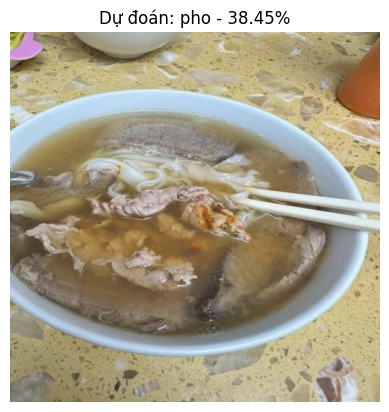

banh_mi: 8.78%
bot_chien: 2.72%
bun: 14.44%
goi_cuon: 35.61%
pho: 38.45%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for file_name in uploaded.keys():
    img = image.load_img(file_name, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]

    pred_idx = np.argmax(preds)
    pred_name = class_names[pred_idx]
    confidence = preds[pred_idx] * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Dự đoán: {pred_name} - {confidence:.2f}%")
    plt.show()

    for name, score in zip(class_names, preds):
        print(f"{name}: {score*100:.2f}%")